In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input,Conv1D,MaxPooling1D,LSTM,Dense,Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

In [2]:
def clean_stock_data(file_path):
    # Load dataset
    df = pd.read_csv(file_path)

    print("Original shape:", df.shape)

    # Convert Date column to datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Sort from oldest to newest
    df = df.sort_values("Date").reset_index(drop=True)

    # Check and remove duplicate rows
    duplicate_rows = df.duplicated().sum()
    print("Duplicate rows:", duplicate_rows)

    df = df.drop_duplicates()

    # Check and remove duplicate dates
    duplicate_dates = df.duplicated(subset=["Date"]).sum()
    print("Duplicate dates:", duplicate_dates)

    df = df.drop_duplicates(subset=["Date"], keep="first")

    # Check missing values
    print("\nMissing values before handling:")
    print(df.isnull().sum())

    # Handle missing values
    price_columns = [
        "Open",
        "High",
        "Low",
        "Close",
        "Adj Close"
    ]

    df[price_columns] = df[price_columns].ffill()
    df[price_columns] = df[price_columns].bfill()

    # Remove observations with missing Volume
    df = df.dropna(subset=["Volume"])

    # Final validation
    df = df.sort_values("Date").reset_index(drop=True)

    print("\nMissing values after handling:")
    print(df.isnull().sum())

    print("\nFinal shape:", df.shape)

    return df

In [3]:
print("===== AAPL =====")
aapl = clean_stock_data("Dataset/AAPL_historical_data.csv")

print("\n===== NVDA =====")
nvda = clean_stock_data("Dataset/NVDA_historical_data.csv")

print("\n===== JPM =====")
jpm = clean_stock_data("Dataset/JPM_historical_data.csv")

print("\n===== BHP =====")
bhp = clean_stock_data("Dataset/BHP.AX_historical_data.csv")

print("\n===== CBA =====")
cba = clean_stock_data("Dataset/CBA.AX_historical_data.csv")

print("\n===== GMG =====")
gmg = clean_stock_data("Dataset/GMG.AX_historical_data.csv")

===== AAPL =====
Original shape: (2010, 7)
Duplicate rows: 0
Duplicate dates: 0

Missing values before handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values after handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Final shape: (2010, 7)

===== NVDA =====
Original shape: (2010, 7)
Duplicate rows: 0
Duplicate dates: 0

Missing values before handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values after handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Final shape: (2010, 7)

===== JPM =====
Original shape: (2010, 7)
Duplicate rows: 0
Duplicate dates: 0

Missing values before handling:
Date         0
Open         0
High         0
Low          0
Close        0
A

In [4]:
print(aapl.head())
print(aapl.tail())

        Date   Open   High    Low  Close  Adj Close     Volume
0 2018-01-02  42.54  43.08  42.31  43.06      40.23  102223600
1 2018-01-03  43.13  43.64  42.99  43.06      40.23  118071600
2 2018-01-04  43.13  43.37  43.02  43.26      40.41   89738400
3 2018-01-05  43.36  43.84  43.26  43.75      40.87   94640000
4 2018-01-08  43.59  43.90  43.48  43.59      40.72   82271200
           Date    Open    High     Low   Close  Adj Close    Volume
2005 2025-12-23  270.84  272.50  269.56  272.36     271.62  29642000
2006 2025-12-24  272.34  275.43  272.20  273.81     273.07  17910600
2007 2025-12-26  274.16  275.37  272.86  273.40     272.66  21521800
2008 2025-12-29  272.69  274.36  272.35  273.76     273.02  23715200
2009 2025-12-30  272.81  274.08  272.28  273.08     272.34  22139600


In [5]:
print(nvda.head())
print(nvda.tail())

        Date  Open  High   Low  Close  Adj Close     Volume
0 2018-01-02  4.89  4.99  4.86   4.98       4.92  355616000
1 2018-01-03  5.10  5.34  5.09   5.31       5.25  914704000
2 2018-01-04  5.39  5.45  5.32   5.34       5.27  583268000
3 2018-01-05  5.35  5.42  5.28   5.39       5.32  580124000
4 2018-01-08  5.51  5.62  5.46   5.55       5.48  881216000
           Date    Open    High     Low   Close  Adj Close     Volume
2005 2025-12-23  182.97  189.33  182.90  189.21     188.98  174873600
2006 2025-12-24  187.94  188.91  186.59  188.61     188.38   65528500
2007 2025-12-26  189.92  192.69  188.00  190.53     190.30  139740300
2008 2025-12-29  187.71  188.76  185.91  188.22     187.99  120006100
2009 2025-12-30  188.24  188.99  186.93  187.54     187.31   97687300


In [6]:
print(jpm.head())
print(jpm.tail())

        Date    Open    High     Low   Close  Adj Close    Volume
0 2018-01-02  107.63  108.02  106.81  107.95      85.52  13578800
1 2018-01-03  107.86  108.49  107.48  108.06      85.60  11901000
2 2018-01-04  108.36  110.03  108.20  109.04      86.83  12953700
3 2018-01-05  109.26  109.55  107.78  108.34      86.27  14155000
4 2018-01-08  108.15  108.68  107.70  108.50      86.40  12466500
           Date    Open    High     Low   Close  Adj Close   Volume
2005 2025-12-23  323.61  327.78  323.09  325.93     321.37  6668300
2006 2025-12-24  326.24  329.99  325.50  329.17     324.56  4289300
2007 2025-12-26  329.11  330.86  326.54  327.91     323.32  4158300
2008 2025-12-29  327.00  327.77  323.53  323.75     319.22  8635300
2009 2025-12-30  324.81  324.94  322.49  323.42     318.89  7904300


In [7]:
print(bhp.head())
print(bhp.tail())

        Date   Open   High    Low  Close  Adj Close   Volume
0 2018-01-02  26.27  26.49  26.27  26.43      14.42  3653331
1 2018-01-03  26.93  27.02  26.86  26.87      14.66  7624353
2 2018-01-04  27.09  27.25  26.98  27.01      14.74  6178215
3 2018-01-05  27.29  27.33  27.17  27.23      14.86  6553946
4 2018-01-08  27.20  27.30  27.10  27.20      14.84  3677542
           Date   Open   High    Low  Close  Adj Close   Volume
2019 2025-12-22  44.85  45.17  44.72  45.07      44.23  5527196
2020 2025-12-23  45.60  45.71  45.30  45.58      44.73  4534942
2021 2025-12-24  45.78  45.78  45.50  45.62      44.77  2112731
2022 2025-12-29  45.90  46.03  45.45  45.45      44.60  4680346
2023 2025-12-30  44.80  45.39  44.70  45.10      44.26  4171339


In [8]:
print(cba.head())
print(cba.tail())

        Date   Open   High    Low  Close  Adj Close   Volume
0 2018-01-02  80.30  80.33  79.78  80.22      55.57  1284609
1 2018-01-03  80.47  80.64  80.06  80.14      55.51  1349269
2 2018-01-04  80.48  80.48  79.81  79.97      55.40  1596303
3 2018-01-05  80.54  81.25  80.37  81.16      56.22  2208531
4 2018-01-08  81.40  81.75  81.30  81.62      56.54  1293549
           Date    Open    High     Low   Close  Adj Close   Volume
2019 2025-12-22  158.00  159.68  157.24  158.26     153.58  1396340
2020 2025-12-23  158.55  161.80  158.55  161.73     156.95  1520620
2021 2025-12-24  161.33  161.50  160.33  161.39     156.62   653329
2022 2025-12-29  161.31  162.24  160.49  160.49     155.74  1091076
2023 2025-12-30  162.25  163.10  161.09  161.29     156.52   995378


In [9]:
print(gmg.head())
print(gmg.tail())

        Date  Open  High   Low  Close  Adj Close   Volume
0 2018-01-02  8.40  8.48  8.34   8.44       7.40  1519605
1 2018-01-03  8.44  8.47  8.36   8.43       7.39  1625146
2 2018-01-04  8.47  8.49  8.39   8.47       7.42  2691250
3 2018-01-05  8.48  8.49  8.35   8.39       7.35  3161786
4 2018-01-08  8.40  8.45  8.37   8.39       7.35  2335220
           Date   Open   High    Low  Close  Adj Close   Volume
2019 2025-12-22  29.09  29.31  28.88  29.22      28.94  2211236
2020 2025-12-23  30.91  31.92  30.68  31.63      31.33  5097836
2021 2025-12-24  31.51  31.67  31.20  31.65      31.35  2150732
2022 2025-12-29  31.54  31.57  30.98  31.32      31.02  2941775
2023 2025-12-30  31.64  31.87  30.77  30.95      30.80  2934635


In [10]:
# Storing all cleaned stock datasets in one dictionary
stocks = {
    "AAPL": aapl,
    "NVDA": nvda,
    "JPM": jpm,
    "BHP": bhp,
    "CBA": cba,
    "GMG": gmg
}

In [11]:
# Storing the summary
summary = []

for stock_name, df in stocks.items():
    
    summary.append({
        "Stock": stock_name,
        "Rows": len(df),
        "Start Date": df["Date"].min(),
        "End Date": df["Date"].max(),
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

# Converting result into a dataframe
summary_df = pd.DataFrame(summary)

summary_df

,Stock,Rows,Start Date,End Date,Missing Values,Duplicate Rows
0,AAPL,2010,2018-01-02,2025-12-30,0,0
1,NVDA,2010,2018-01-02,2025-12-30,0,0
2,JPM,2010,2018-01-02,2025-12-30,0,0
3,BHP,2024,2018-01-02,2025-12-30,0,0
4,CBA,2024,2018-01-02,2025-12-30,0,0
5,GMG,2024,2018-01-02,2025-12-30,0,0


In [12]:
# Summary statistics for each stock
for stock_name, df in stocks.items():
    
    print("\n", stock_name)
    
    print(df[
        ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    ].describe())


 AAPL
              Open         High          Low        Close    Adj Close  \
count  2010.000000  2010.000000  2010.000000  2010.000000  2010.000000   
mean    137.498756   139.022338   136.103622   137.632085   135.080836   
std      66.203729    66.845908    65.621446    66.269856    66.581243   
min      35.990000    36.430000    35.500000    35.550000    33.710000   
25%      66.500000    67.170000    65.777500    66.625000    64.207500   
50%     145.510000   147.230000   144.105000   145.860000   142.545000   
75%     184.395000   186.490000   182.642500   184.742500   182.357500   
max     286.200000   288.620000   283.300000   286.190000   285.410000   

             Volume  
count  2.010000e+03  
mean   9.446075e+07  
std    5.446452e+07  
min    1.791060e+07  
25%    5.564338e+07  
50%    8.098160e+07  
75%    1.151486e+08  
max    4.265100e+08  

 NVDA
              Open         High          Low        Close    Adj Close  \
count  2010.000000  2010.000000  2010.000000  2

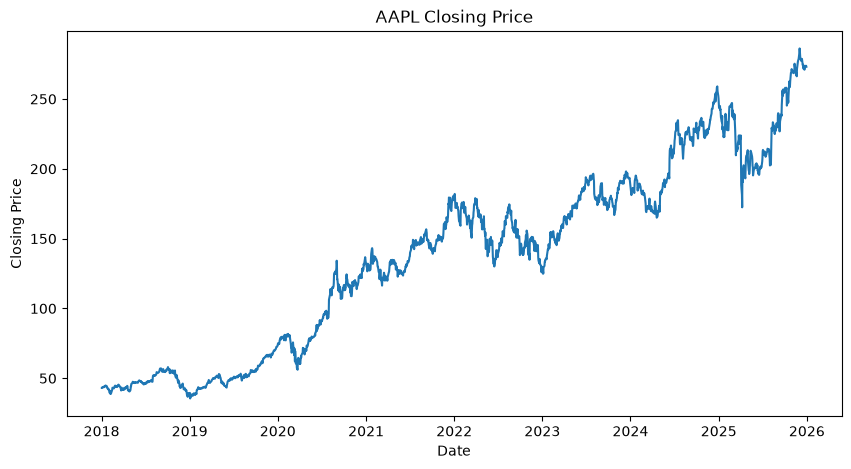

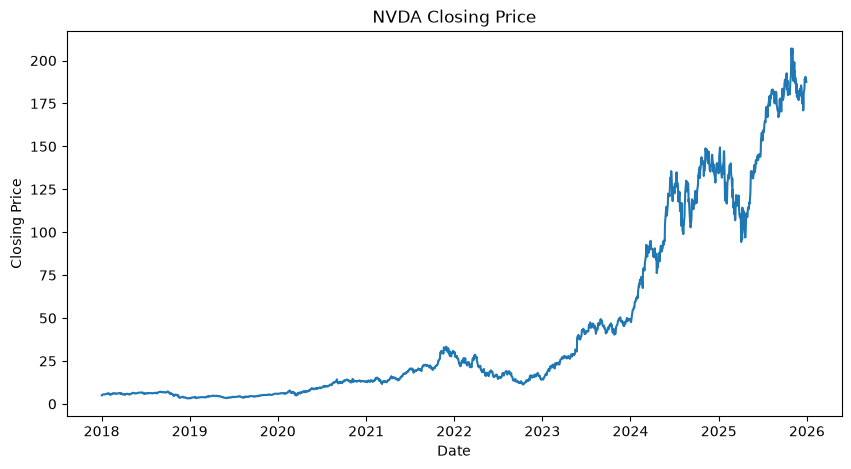

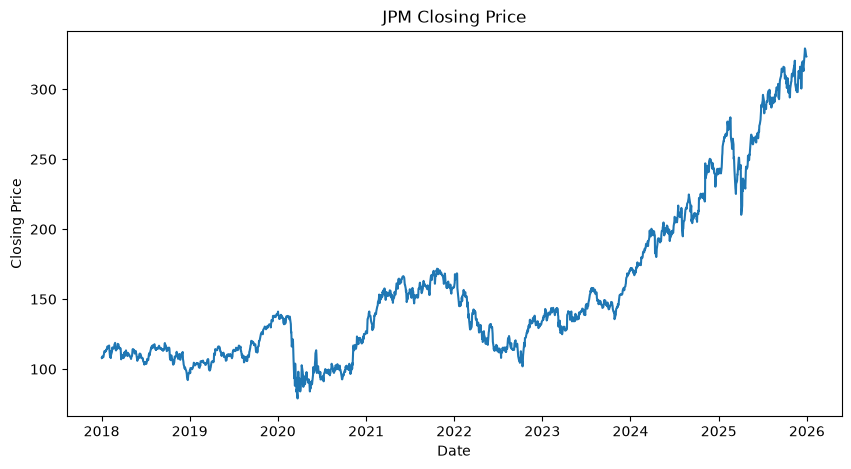

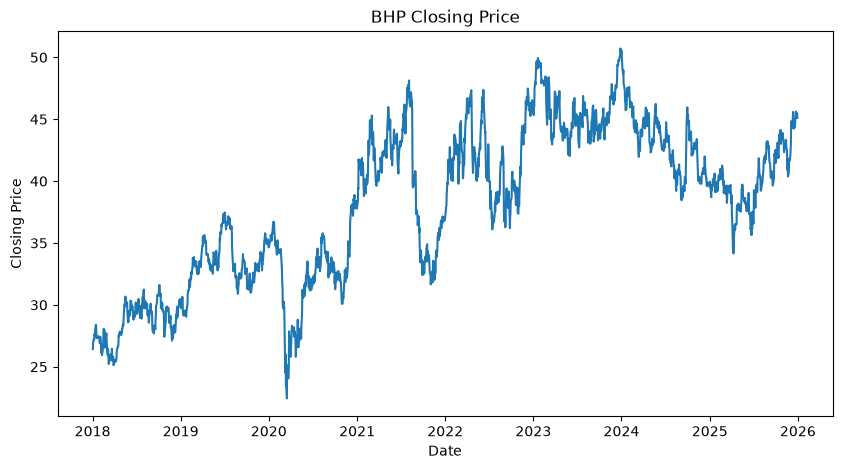

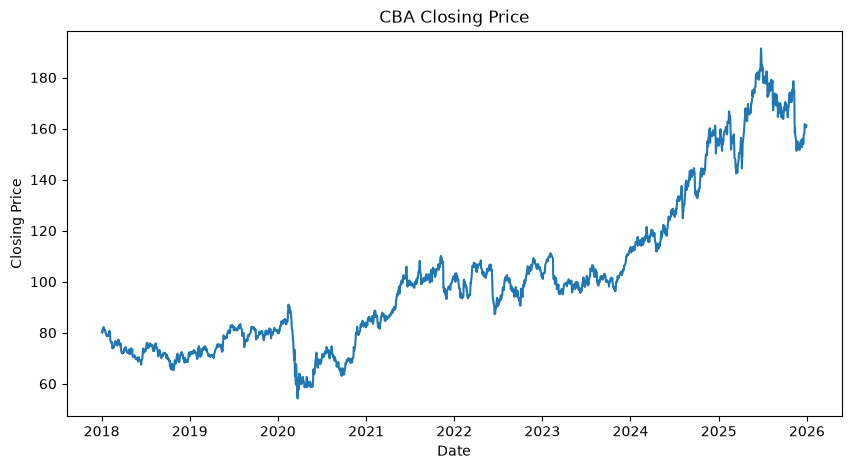

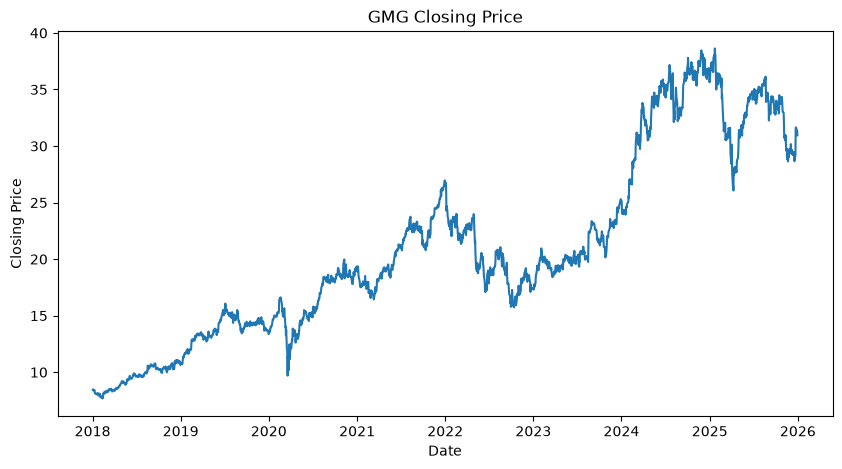

In [13]:
# Plotting the closing price over time
for stock_name, df in stocks.items():
    
    plt.figure(figsize=(10, 5))
    
    plt.plot(df["Date"], df["Close"])
    
    plt.title(stock_name + " Closing Price")
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    
    plt.show()

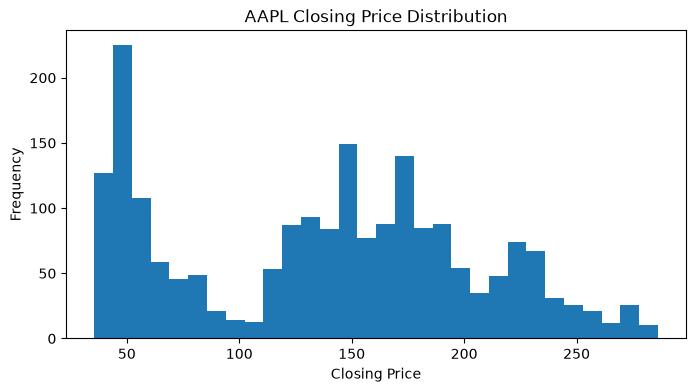

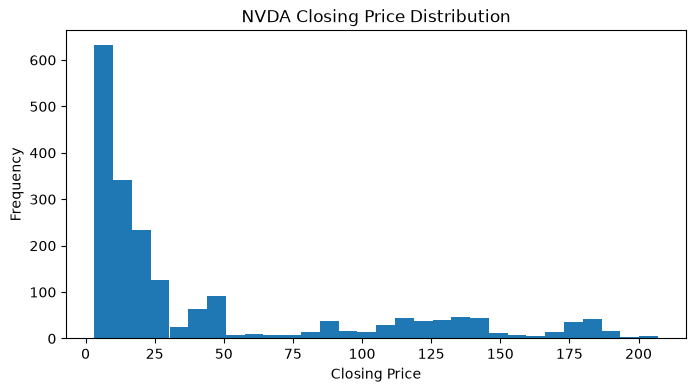

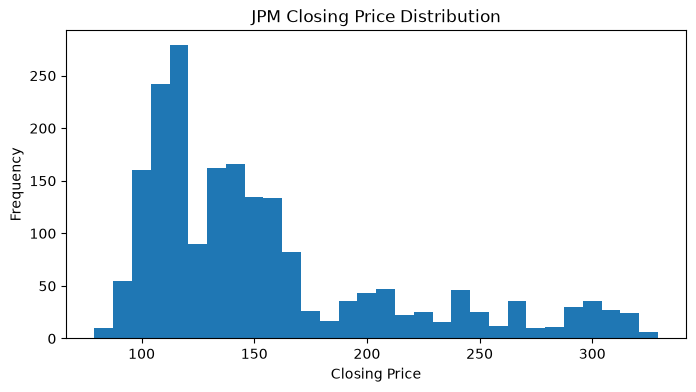

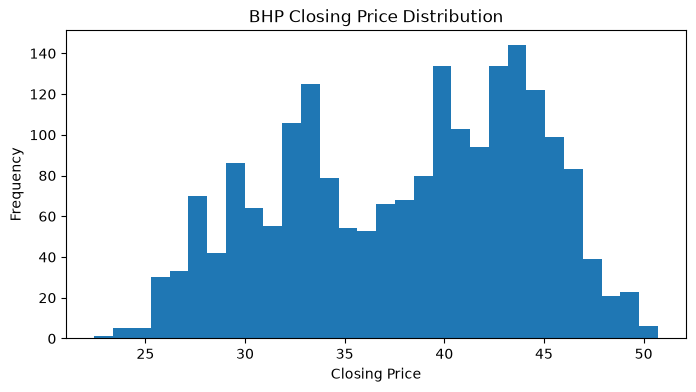

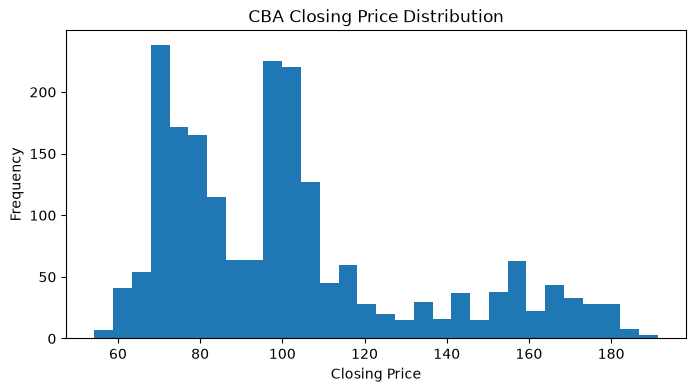

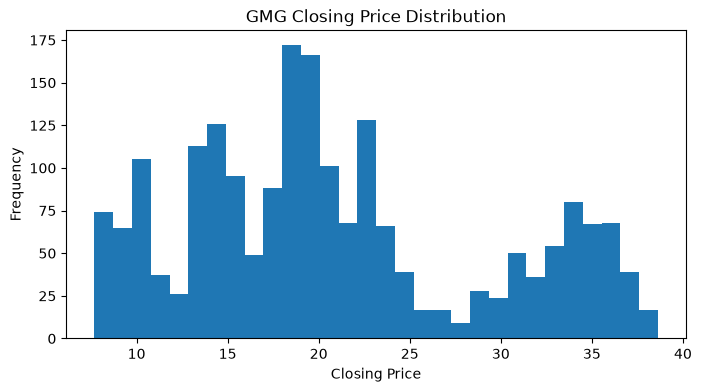

In [14]:
# Distribution of closing prices
for stock_name, df in stocks.items():
    
    plt.figure(figsize=(8, 4))
    
    plt.hist(df["Close"], bins=30)
    
    plt.title(stock_name + " Closing Price Distribution")
    plt.xlabel("Closing Price")
    plt.ylabel("Frequency")
    
    plt.show()

In [15]:
# Checking IQR outliers in closing prices
for stock_name, df in stocks.items():

    Q1 = df["Close"].quantile(0.25)
    Q3 = df["Close"].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df["Close"] < lower_limit) |
        (df["Close"] > upper_limit)
    ]

    print(stock_name)
    print("Lower limit:", round(lower_limit, 2))
    print("Upper limit:", round(upper_limit, 2))
    print("Number of outliers:", len(outliers))
    print()

AAPL
Lower limit: -110.55
Upper limit: 361.92
Number of outliers: 0

NVDA
Lower limit: -57.95
Upper limit: 114.0
Number of outliers: 347

JPM
Lower limit: 27.94
Upper limit: 255.69
Number of outliers: 191

BHP
Lower limit: 17.13
Upper limit: 59.12
Number of outliers: 0

CBA
Lower limit: 24.41
Upper limit: 164.26
Number of outliers: 143

GMG
Lower limit: -1.43
Upper limit: 41.22
Number of outliers: 0



In [16]:
# Checking date range of IQR outliers
for stock_name, df in stocks.items():

    Q1 = df["Close"].quantile(0.25)
    Q3 = df["Close"].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df["Close"] < lower_limit) |
        (df["Close"] > upper_limit)
    ]

    if len(outliers) > 0:
        print(stock_name)
        print("Number of outliers:", len(outliers))
        print("First outlier:", outliers["Date"].min())
        print("Last outlier:", outliers["Date"].max())
        print()

NVDA
Number of outliers: 347
First outlier: 2024-05-29 00:00:00
Last outlier: 2025-12-30 00:00:00

JPM
Number of outliers: 191
First outlier: 2025-01-17 00:00:00
Last outlier: 2025-12-30 00:00:00

CBA
Number of outliers: 143
First outlier: 2025-02-12 00:00:00
Last outlier: 2025-11-10 00:00:00



In [17]:
# Feature Selection
feature_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

target_column = "Target"

print("Features used:", feature_columns)

Features used: ['Open', 'High', 'Low', 'Close', 'Volume']


In [18]:
# Create Target Variable
# Predict next trading day's closing price
for stock_name in stocks:

    stocks[stock_name]["Target"] = (
        stocks[stock_name]["Close"].shift(-1)
    )

    # Last row has no next-day Close
    stocks[stock_name] = (
        stocks[stock_name]
        .dropna(subset=["Target"])
        .reset_index(drop=True)
    )

print("Next-day target created for all stocks.")

Next-day target created for all stocks.


In [19]:
print(
    stocks["AAPL"][
        ["Date", "Close", "Target"]
    ].head(10)
)

        Date  Close  Target
0 2018-01-02  43.06   43.06
1 2018-01-03  43.06   43.26
2 2018-01-04  43.26   43.75
3 2018-01-05  43.75   43.59
4 2018-01-08  43.59   43.58
5 2018-01-09  43.58   43.57
6 2018-01-10  43.57   43.82
7 2018-01-11  43.82   44.27
8 2018-01-12  44.27   44.05
9 2018-01-16  44.05   44.78


In [20]:
# Chronological Train / Validation / Test
def chronological_split(
    df,
    train_ratio=0.70,
    val_ratio=0.15
):

    n = len(df)

    train_end = int(n * train_ratio)

    val_end = int(
        n * (train_ratio + val_ratio)
    )

    train = df.iloc[
        :train_end
    ].copy()

    validation = df.iloc[
        train_end:val_end
    ].copy()

    test = df.iloc[
        val_end:
    ].copy()

    return train, validation, test

splits = {}

for stock_name, df in stocks.items():

    train, validation, test = (
        chronological_split(df)
    )

    splits[stock_name] = {
        "train": train,
        "validation": validation,
        "test": test
    }

    print(f"\n{stock_name}")

    print(
        "Training:",
        len(train)
    )

    print(
        "Validation:",
        len(validation)
    )

    print(
        "Testing:",
        len(test)
    )


AAPL
Training: 1406
Validation: 301
Testing: 302

NVDA
Training: 1406
Validation: 301
Testing: 302

JPM
Training: 1406
Validation: 301
Testing: 302

BHP
Training: 1416
Validation: 303
Testing: 304

CBA
Training: 1416
Validation: 303
Testing: 304

GMG
Training: 1416
Validation: 303
Testing: 304


In [21]:
# Check date ranges for train, validation, and test splits
for stock_name, data in splits.items():

    print(f"\n{stock_name}")

    print(
        "Train:",
        data["train"]["Date"].min().date(),
        "to",
        data["train"]["Date"].max().date()
    )

    print(
        "Validation:",
        data["validation"]["Date"].min().date(),
        "to",
        data["validation"]["Date"].max().date()
    )

    print(
        "Test:",
        data["test"]["Date"].min().date(),
        "to",
        data["test"]["Date"].max().date()
    )


AAPL
Train: 2018-01-02 to 2023-08-03
Validation: 2023-08-04 to 2024-10-14
Test: 2024-10-15 to 2025-12-29

NVDA
Train: 2018-01-02 to 2023-08-03
Validation: 2023-08-04 to 2024-10-14
Test: 2024-10-15 to 2025-12-29

JPM
Train: 2018-01-02 to 2023-08-03
Validation: 2023-08-04 to 2024-10-14
Test: 2024-10-15 to 2025-12-29

BHP
Train: 2018-01-02 to 2023-08-07
Validation: 2023-08-08 to 2024-10-15
Test: 2024-10-16 to 2025-12-29

CBA
Train: 2018-01-02 to 2023-08-07
Validation: 2023-08-08 to 2024-10-15
Test: 2024-10-16 to 2025-12-29

GMG
Train: 2018-01-02 to 2023-08-07
Validation: 2023-08-08 to 2024-10-15
Test: 2024-10-16 to 2025-12-29


In [22]:
# Min-Max scaling
scaled_splits = {}
scalers = {}

for stock_name, data in splits.items():

    train = data["train"].copy()

    validation = data[
        "validation"
    ].copy()

    test = data["test"].copy()

    # Separate scaler for features
    feature_scaler = MinMaxScaler(
        feature_range=(0, 1)
    )

    # Separate scaler for target
    target_scaler = MinMaxScaler(
        feature_range=(0, 1)
    )

    # Fit ONLY on training data
    feature_scaler.fit(
        train[feature_columns]
    )

    target_scaler.fit(
        train[[target_column]]
    )

    # Transform input features
    X_train = feature_scaler.transform(
        train[feature_columns]
    )

    X_val = feature_scaler.transform(
        validation[feature_columns]
    )

    X_test = feature_scaler.transform(
        test[feature_columns]
    )

    # Transform targets
    y_train = target_scaler.transform(
        train[[target_column]]
    )

    y_val = target_scaler.transform(
        validation[[target_column]]
    )

    y_test = target_scaler.transform(
        test[[target_column]]
    )

    scaled_splits[stock_name] = {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test
    }

    scalers[stock_name] = {
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler
    }

    print(
        f"{stock_name} scaling completed."
    )

AAPL scaling completed.
NVDA scaling completed.
JPM scaling completed.
BHP scaling completed.
CBA scaling completed.
GMG scaling completed.


In [23]:
# Check shapes
for stock_name, data in scaled_splits.items():

    print(f"\n{stock_name}")

    print(
        "X_train:",
        data["X_train"].shape
    )

    print(
        "X_val:",
        data["X_val"].shape
    )

    print(
        "X_test:",
        data["X_test"].shape
    )

    print(
        "y_train:",
        data["y_train"].shape
    )

    print(
        "y_val:",
        data["y_val"].shape
    )

    print(
        "y_test:",
        data["y_test"].shape
    )


AAPL
X_train: (1406, 5)
X_val: (301, 5)
X_test: (302, 5)
y_train: (1406, 1)
y_val: (301, 1)
y_test: (302, 1)

NVDA
X_train: (1406, 5)
X_val: (301, 5)
X_test: (302, 5)
y_train: (1406, 1)
y_val: (301, 1)
y_test: (302, 1)

JPM
X_train: (1406, 5)
X_val: (301, 5)
X_test: (302, 5)
y_train: (1406, 1)
y_val: (301, 1)
y_test: (302, 1)

BHP
X_train: (1416, 5)
X_val: (303, 5)
X_test: (304, 5)
y_train: (1416, 1)
y_val: (303, 1)
y_test: (304, 1)

CBA
X_train: (1416, 5)
X_val: (303, 5)
X_test: (304, 5)
y_train: (1416, 1)
y_val: (303, 1)
y_test: (304, 1)

GMG
X_train: (1416, 5)
X_val: (303, 5)
X_test: (304, 5)
y_train: (1416, 1)
y_val: (303, 1)
y_test: (304, 1)


In [24]:
# Create 60-Day Sequences
LOOKBACK = 60

def make_sequences(
    X,
    y,
    lookback=60
):

    X_seq = []
    y_seq = []

    # Start at index lookback - 1
    # so current row is included
    for i in range(
        lookback - 1,
        len(X)
    ):

        X_seq.append(
            X[
                i - lookback + 1:
                i + 1
            ]
        )

        y_seq.append(
            y[i]
        )

    return (
        np.asarray(X_seq),
        np.asarray(y_seq)
    )

In [25]:
# Create Sequences for All Stocks
sequence_data = {}

for stock_name, data in scaled_splits.items():

    X_train = data["X_train"]
    y_train = data["y_train"]

    X_val = data["X_val"]
    y_val = data["y_val"]

    X_test = data["X_test"]
    y_test = data["y_test"]

    # Training sequences
    X_train_seq, y_train_seq = (
        make_sequences(
            X_train,
            y_train,
            LOOKBACK
        )
    )

    # Validation
    # Use final 59 training observations as historical context
    X_val_context = np.concatenate(
        [
            X_train[-(LOOKBACK - 1):],
            X_val
        ],
        axis=0
    )

    y_val_context = np.concatenate(
        [
            y_train[-(LOOKBACK - 1):],
            y_val
        ],
        axis=0
    )

    X_val_seq, y_val_seq = (
        make_sequences(
            X_val_context,
            y_val_context,
            LOOKBACK
        )
    )

    # Testing
    # Use final 59 validation observations as historical context
    X_test_context = np.concatenate(
        [
            X_val[-(LOOKBACK - 1):],
            X_test
        ],
        axis=0
    )

    y_test_context = np.concatenate(
        [
            y_val[-(LOOKBACK - 1):],
            y_test
        ],
        axis=0
    )

    X_test_seq, y_test_seq = (
        make_sequences(
            X_test_context,
            y_test_context,
            LOOKBACK
        )
    )

    sequence_data[stock_name] = {
        "X_train": X_train_seq,
        "y_train": y_train_seq,
        "X_val": X_val_seq,
        "y_val": y_val_seq,
        "X_test": X_test_seq,
        "y_test": y_test_seq
    }

    print(f"\n{stock_name}")

    print(
        "Train:",
        X_train_seq.shape,
        y_train_seq.shape
    )

    print(
        "Validation:",
        X_val_seq.shape,
        y_val_seq.shape
    )

    print(
        "Test:",
        X_test_seq.shape,
        y_test_seq.shape
    )


AAPL
Train: (1347, 60, 5) (1347, 1)
Validation: (301, 60, 5) (301, 1)
Test: (302, 60, 5) (302, 1)

NVDA
Train: (1347, 60, 5) (1347, 1)
Validation: (301, 60, 5) (301, 1)
Test: (302, 60, 5) (302, 1)

JPM
Train: (1347, 60, 5) (1347, 1)
Validation: (301, 60, 5) (301, 1)
Test: (302, 60, 5) (302, 1)

BHP
Train: (1357, 60, 5) (1357, 1)
Validation: (303, 60, 5) (303, 1)
Test: (304, 60, 5) (304, 1)

CBA
Train: (1357, 60, 5) (1357, 1)
Validation: (303, 60, 5) (303, 1)
Test: (304, 60, 5) (304, 1)

GMG
Train: (1357, 60, 5) (1357, 1)
Validation: (303, 60, 5) (303, 1)
Test: (304, 60, 5) (304, 1)


In [26]:
# Validate sequence shapes and split lengths for all stocks
for stock_name, data in sequence_data.items():

    assert (
        data["X_train"].shape[1]
        == LOOKBACK
    )

    assert (
        data["X_train"].shape[2]
        == len(feature_columns)
    )

    assert (
        len(data["X_val"])
        == len(splits[stock_name]["validation"])
    )

    assert (
        len(data["X_test"])
        == len(splits[stock_name]["test"])
    )

print(
    "All sequence shapes and split "
    "lengths are correct."
)

All sequence shapes and split lengths are correct.
